## AI-Detection 

Vincent Luong

### Importing Libaries

In [1]:
import numpy as np
import pandas as pd
import os
import glob
import sys

# Must be set BEFORE importing tensorflow
os.environ["TF_NUM_INTRAOP_THREADS"] = "0"
os.environ["TF_NUM_INTEROP_THREADS"] = "0"

import tensorflow as tf

tf.config.threading.set_intra_op_parallelism_threads(12)
tf.config.threading.set_inter_op_parallelism_threads(12)

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import metrics
from keras.models import load_model
from keras.preprocessing import image
from tensorflow.keras import layers, models
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

In [2]:
print(os.cpu_count())

12


## Refering to Data

In [3]:
CFG = {
    "train_dir": "data/real-vs-fake/train",
    "test_dir":  "data/real-vs-fake/test",
    "img_size":  (160, 160),
    "batch_size": 64,
    "epochs":    15,
    "seed":      42,
}

In [5]:
for split in ["train", "test"]:
    split_dir = os.path.join("data/real-vs-fake", split)
    for cls in sorted(os.listdir(split_dir)):
        cls_path = os.path.join(split_dir, cls)
        if os.path.isdir(cls_path):
            count = len(glob.glob(os.path.join(cls_path, "*.jpg")))
            print(f"  [{split}] {cls}: {count} images")

CLASS_NAMES = ["fake", "real"] 

  [train] fake: 20234 images
  [train] real: 18895 images
  [test] fake: 10000 images
  [test] real: 10000 images


## Creating Train, Validation, and Test Split

In [7]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    CFG["train_dir"],
    labels="inferred",
    label_mode="binary",
    class_names=CLASS_NAMES,
    image_size=CFG["img_size"],
    batch_size=CFG["batch_size"],
    shuffle=True,
    seed=CFG["seed"],
    validation_split=0.2,
    subset="training",
)

Found 37540 files belonging to 2 classes.
Using 30032 files for training.


In [5]:
# import shutil

# # Remove any .ipynb_checkpoints folders inside the data directory
# for root, dirs, files in os.walk("data"):
#     for d in dirs:
#         if d == ".ipynb_checkpoints":
#             path = os.path.join(root, d)
#             shutil.rmtree(path)
#             print(f"Deleted: {path}")

# print("Done — re-run the dataset cells now.")

In [8]:
val_ds = tf.keras.utils.image_dataset_from_directory(
    CFG["train_dir"],
    labels="inferred",
    label_mode="binary",
    class_names=CLASS_NAMES,
    image_size=CFG["img_size"],
    batch_size=CFG["batch_size"],
    shuffle=False,
    seed=CFG["seed"],
    validation_split=0.2,
    subset="validation",
)


Found 37540 files belonging to 2 classes.
Using 7508 files for validation.


In [9]:
test_ds = tf.keras.utils.image_dataset_from_directory(
    CFG["test_dir"],
    labels="inferred",
    label_mode="binary",
    class_names=CLASS_NAMES,
    image_size=CFG["img_size"],
    batch_size=CFG["batch_size"],
    shuffle=False,
)
print(f"\nClasses: {CLASS_NAMES}")

Found 20000 files belonging to 2 classes.

Classes: ['fake', 'real']


In [10]:
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().prefetch(AUTOTUNE)
val_ds   = val_ds.cache().prefetch(AUTOTUNE)
test_ds  = test_ds.prefetch(AUTOTUNE)

## Seeing Sample Batch

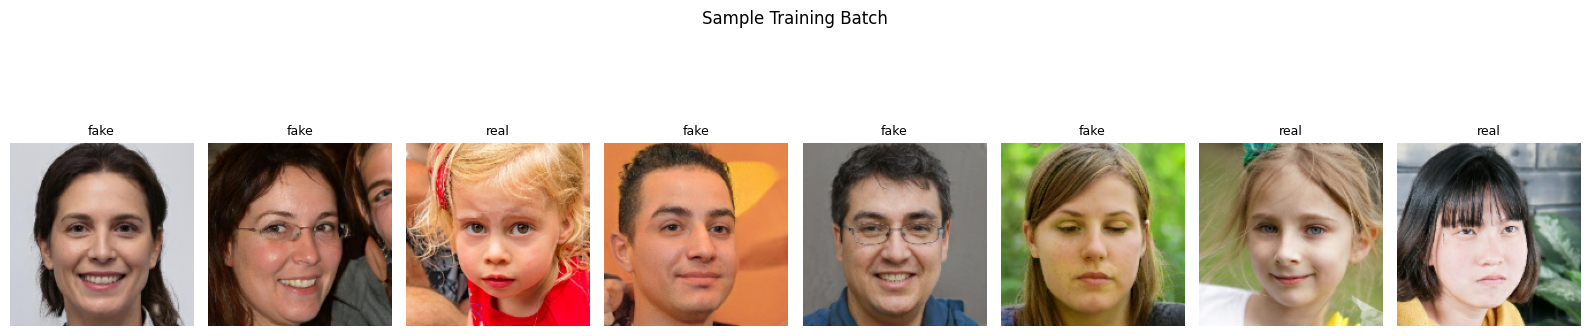

In [11]:
plt.figure(figsize=(16, 4))
for imgs, labels in train_ds.take(1):
    for i in range(8):
        plt.subplot(1, 8, i+1)
        plt.imshow(imgs[i].numpy().astype("uint8"))
        plt.title(CLASS_NAMES[int(labels[i])], fontsize=9)
        plt.axis("off")
plt.suptitle("Sample Training Batch", y=1.02)
plt.tight_layout()
plt.show()

## Preprocessing

In [12]:
augment = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
    layers.RandomBrightness(0.2),
], name="augmentation")


preprocess_input = tf.keras.applications.resnet50.preprocess_input

In [14]:
# def build_model():
#     base = ResNet50(
#         weights="imagenet",
#         include_top=False,
#         input_shape=(*CFG["img_size"], 3),
#     )
#     base.trainable = False          # freeze backbone to start

#     inputs = layers.Input(shape=(*CFG["img_size"], 3))
#     x = augment(inputs)             # augmentation only active during training
#     x = preprocess_input(x)         # ResNet-specific normalisation
#     x = base(x, training=False)
#     x = layers.GlobalAveragePooling2D()(x)
#     x = layers.Dropout(0.3)(x)
#     x = layers.Dense(256, activation="relu")(x)
#     x = layers.Dropout(0.2)(x)
#     outputs = layers.Dense(1, activation="sigmoid")(x)  # binary output

#     return tf.keras.Model(inputs, outputs)

# model = build_model()
# model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)    │ (None, 160, 160, 3)       │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ augmentation (Sequential)     │ (None, 160, 160, 3)       │               0 │ input_layer_1[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ get_item (GetItem)            │ (None, 160, 160)          │               0 │ augmentation[0][0]         │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ get_item_1 (GetItem)          │ (None, 160, 160)          │               0 │ augmentation[0][0]         │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ get_item_2 (GetItem)          │ (None, 160, 160)          │               0 │ augmentation[0][0]         │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ stack (Stack)                 │ (None, 160, 160, 3)       │               0 │ get_item[0][0],            │
│                               │                           │                 │ get_item_1[0][0],          │
│                               │                           │                 │ get_item_2[0][0]           │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ add (Add)                     │ (None, 160, 160, 3)       │               0 │ stack[0][0]                │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ resnet50 (Functional)         │ (None, 5, 5, 2048)        │      23,587,712 │ add[0][0]                  │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ global_average_pooling2d      │ (None, 2048)              │               0 │ resnet50[0][0]             │
│ (GlobalAveragePooling2D)      │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dropout (Dropout)             │ (None, 2048)              │               0 │ global_average_pooling2d[… │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense (Dense)                 │ (None, 256)               │         524,544 │ dropout[0][0]              │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dropout_1 (Dropout)           │ (None, 256)               │               0 │ dense[0][0]                │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense_1 (Dense)               │ (None, 1)                 │             257 │ dropout_1[0][0]            │
└───────────────────────────────┴───────────────────────────┴─────────────────┴────────────────────────────┘

 Total params: 24,112,513 (91.98 MB)

 Trainable params: 524,801 (2.00 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

## Traing Model

In [18]:
# # Fix AUC bug - change label_mode to int then use standard AUC
# model = build_model()
# model.compile(
#     optimizer=tf.keras.optimizers.Adam(1e-3),
#     loss="binary_crossentropy",
#     metrics=[
#         "accuracy",
#         tf.keras.metrics.AUC(name="auc", curve="ROC", from_logits=False),
#         tf.keras.metrics.Precision(name="precision"),
#         tf.keras.metrics.Recall(name="recall"),
#     ]
# )

# # Update callbacks to monitor val_loss instead of val_auc
# callbacks = [stardew valley
#     EarlyStopping(monitor="val_loss", patience=4, mode="min", restore_best_weights=True),
#     ModelCheckpoint("best_model.keras", monitor="val_loss", mode="min", save_best_only=True),
#     ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=2, min_lr=1e-6, verbose=1),
#     tf.keras.callbacks.CSVLogger("training_log.csv", append=True),
# ]

# model.fit(
#     train_ds,
#     validation_data=val_ds,
#     initial_epoch=0,
#     epochs=CFG["epochs"],
#     callbacks=callbacks,
# )

Epoch 1/15
470/470 ━━━━━━━━━━━━━━━━━━━━ 860s 2s/step - accuracy: 0.6944 - auc: 0.7616 - loss: 0.5866 - precision: 0.6923 - recall: 0.6731 - val_accuracy: 0.6484 - val_auc: 0.0000e+00 - val_loss: 0.6095 - val_precision: 1.0000 - val_recall: 0.6484 - learning_rate: 0.0010
Epoch 2/15
470/470 ━━━━━━━━━━━━━━━━━━━━ 824s 2s/step - accuracy: 0.7349 - auc: 0.8104 - loss: 0.5305 - precision: 0.7351 - recall: 0.7145 - val_accuracy: 0.8029 - val_auc: 0.0000e+00 - val_loss: 0.4093 - val_precision: 1.0000 - val_recall: 0.8029 - learning_rate: 0.0010
Epoch 3/15
470/470 ━━━━━━━━━━━━━━━━━━━━ 880s 2s/step - accuracy: 0.7506 - auc: 0.8269 - loss: 0.5120 - precision: 0.7484 - recall: 0.7369 - val_accuracy: 0.7433 - val_auc: 0.0000e+00 - val_loss: 0.4930 - val_precision: 1.0000 - val_recall: 0.7433 - learning_rate: 0.0010
Epoch 4/15
470/470 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.7542 - auc: 0.8345 - loss: 0.5012 - precision: 0.7570 - recall: 0.7279
Epoch 4: ReduceLROnPlateau reducing learning rate t

## Saving Progress

In [13]:
model = tf.keras.models.load_model("best_model.keras")

In [14]:
log = pd.read_csv("training_log.csv")
print(log)

    epoch  accuracy       auc  learning_rate      loss  precision    recall  \
0       0  0.694359  0.761611        0.00100  0.586597   0.692318  0.673101   
1       1  0.734916  0.810402        0.00100  0.530481   0.735106  0.714500   
2       2  0.750599  0.826895        0.00100  0.512016   0.748407  0.736871   
3       3  0.758657  0.838107        0.00100  0.497031   0.759158  0.740622   
4       4  0.771710  0.853014        0.00050  0.475996   0.772100  0.755354   
5       5  0.777404  0.859685        0.00050  0.465968   0.777268  0.762584   
6       6  0.784563  0.863873        0.00050  0.460299   0.785276  0.768995   
7       7  0.788725  0.869174        0.00050  0.452064   0.787447  0.776974   
8       8  0.789358  0.871597        0.00050  0.448232   0.790089  0.774246   
9       9  0.793287  0.874573        0.00050  0.443501   0.792647  0.780862   
10     10  0.801612  0.881240        0.00050  0.432552   0.800179  0.791229   
11     11  0.794353  0.879105        0.00050  0.4355

In [15]:
results = model.evaluate(val_ds)
print(dict(zip(model.metrics_names, results)))

118/118 ━━━━━━━━━━━━━━━━━━━━ 182s 2s/step - accuracy: 0.9020 - auc: 0.0000e+00 - loss: 0.2554 - precision: 1.0000 - recall: 0.9020
{'loss': 0.2554289698600769, 'compile_metrics': 0.9019712209701538}


In [17]:
# Evaluate the model on the test set
test_acc = model.evaluate(test_ds)
print("Test Accuracy:", test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 413s 1s/step - accuracy: 0.8248 - auc: 0.9127 - loss: 0.3958 - precision: 0.7851 - recall: 0.8944
Test Accuracy: [0.3958415389060974, 0.8248000144958496, 0.9126676917076111, 0.7851123809814453, 0.8944000005722046]


In [18]:
print(dict(zip(model.metrics_names, test_acc)))

{'loss': 0.3958415389060974, 'compile_metrics': 0.8248000144958496}


## Importing New Data

In [6]:
model = tf.keras.models.load_model("best_model.keras")

In [10]:
import shutil
import os

# Copy AI images → fake
for img in os.listdir("data/AI-face-detection-Dataset/AI"):
    shutil.copy(
        f"data/AI-face-detection-Dataset/AI/{img}",
        f"data/real-vs-fake/train/fake/{img}"
    )

# Copy real images → real
for img in os.listdir("data/AI-face-detection-Dataset/real"):
    shutil.copy(
        f"data/AI-face-detection-Dataset/real/{img}",
        f"data/real-vs-fake/train/real/{img}"
    )

# Sanity check
print("fake:", len(os.listdir("data/AI-face-detection-Dataset/AI")))
print("real:", len(os.listdir("data/AI-face-detection-Dataset/real")))

fake: 1001
real: 2202


In [17]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    "data/real-vs-fake/train",
    validation_split=0.2,
    subset="training",
    seed=42,
    image_size=(160, 160),
    batch_size=64,
    label_mode="int"
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    "data/real-vs-fake/train",
    validation_split=0.2,
    subset="validation",
    seed=42,
    image_size=(160, 160),
    batch_size=64,
    label_mode="int"
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    "data/real-vs-fake/test",
    image_size=(160, 160),
    batch_size=64,
    label_mode="int"
)

Found 29224 files belonging to 2 classes.
Found 6528 files belonging to 2 classes.
Found 6514 files belonging to 2 classes.


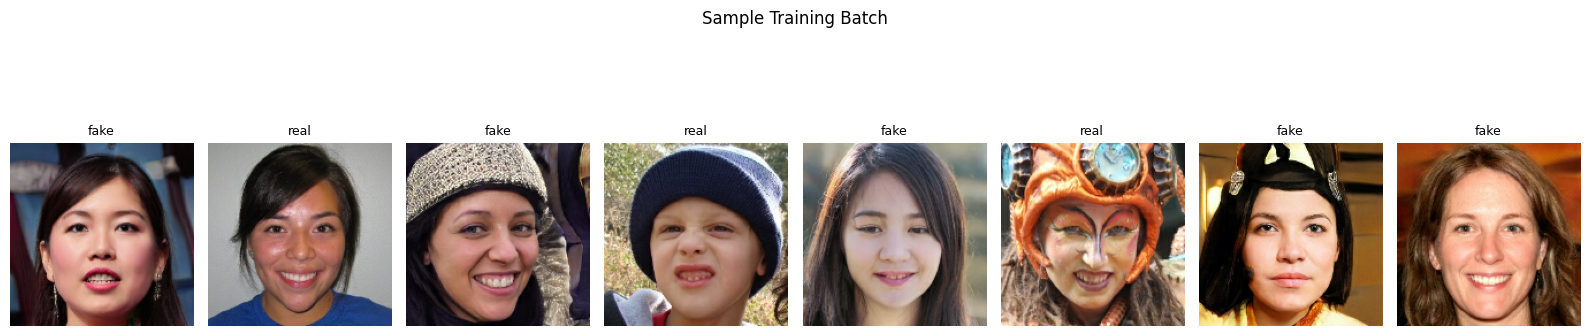

In [11]:
plt.figure(figsize=(16, 4))
for imgs, labels in train_ds.take(1):
    for i in range(8):
        plt.subplot(1, 8, i+1)
        plt.imshow(imgs[i].numpy().astype("uint8"))
        plt.title(CLASS_NAMES[int(labels[i])], fontsize=9)
        plt.axis("off")
plt.suptitle("Sample Training Batch", y=1.02)
plt.tight_layout()
plt.show()

In [35]:
model = tf.keras.models.load_model("best_model.keras")

In [36]:
log = pd.read_csv("training_log.csv")
last_epoch = int(log["epoch"].max()) + 1

In [37]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-4),
    loss="binary_crossentropy",
    metrics=[
        "accuracy",
        tf.keras.metrics.AUC(name="auc", curve="ROC", from_logits=False),
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.Recall(name="recall"),
    ]
)

In [38]:
callbacks = [
    tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=4, restore_best_weights=True),
    tf.keras.callbacks.ModelCheckpoint("best_model.keras", monitor="val_loss", save_best_only=True),
    tf.keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=2, min_lr=1e-6, verbose=1),
    tf.keras.callbacks.CSVLogger("training_log.csv", append=True),
]

## Retrain Model on New Data

In [39]:
# model.fit(
#     train_ds,
#     validation_data=val_ds,
#     initial_epoch=last_epoch,
#     epochs=last_epoch + 20,
#     callbacks=callbacks,
# )

Epoch 16/35
510/510 ━━━━━━━━━━━━━━━━━━━━ 957s 2s/step - accuracy: 0.7950 - auc: 0.8795 - loss: 0.4360 - precision: 0.7965 - recall: 0.7969 - val_accuracy: 0.8479 - val_auc: 0.9318 - val_loss: 0.3633 - val_precision: 0.8151 - val_recall: 0.9001 - learning_rate: 1.0000e-04
Epoch 17/35
510/510 ━━━━━━━━━━━━━━━━━━━━ 907s 2s/step - accuracy: 0.8052 - auc: 0.8878 - loss: 0.4208 - precision: 0.8092 - recall: 0.8030 - val_accuracy: 0.8462 - val_auc: 0.9331 - val_loss: 0.3613 - val_precision: 0.8083 - val_recall: 0.9077 - learning_rate: 1.0000e-04
Epoch 18/35
510/510 ━━━━━━━━━━━━━━━━━━━━ 912s 2s/step - accuracy: 0.8070 - auc: 0.8910 - loss: 0.4154 - precision: 0.8121 - recall: 0.8030 - val_accuracy: 0.8489 - val_auc: 0.9369 - val_loss: 0.3507 - val_precision: 0.8147 - val_recall: 0.9033 - learning_rate: 1.0000e-04
Epoch 19/35
510/510 ━━━━━━━━━━━━━━━━━━━━ 900s 2s/step - accuracy: 0.8134 - auc: 0.8940 - loss: 0.4104 - precision: 0.8210 - recall: 0.8054 - val_accuracy: 0.8551 - val_auc: 0.9389 - va

## Loss, Accuracy, and AUC Graphs

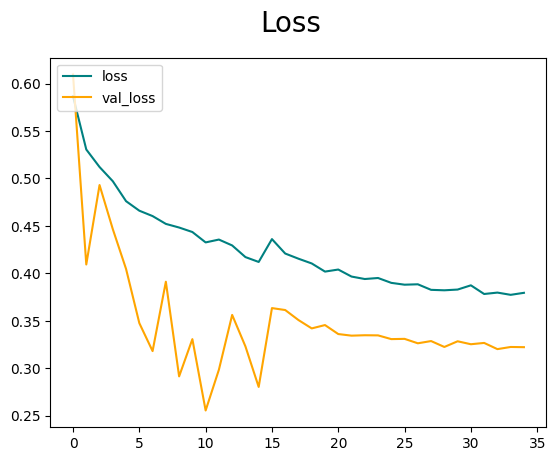

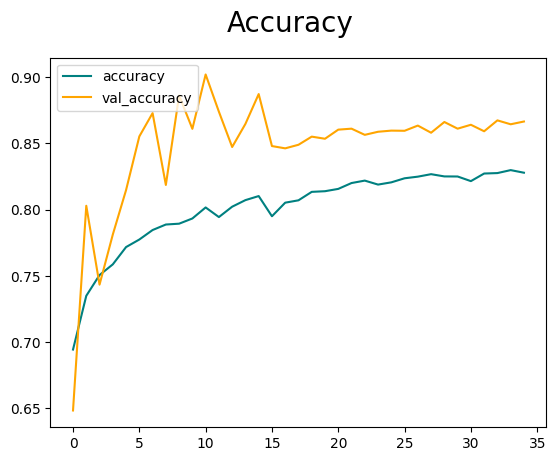

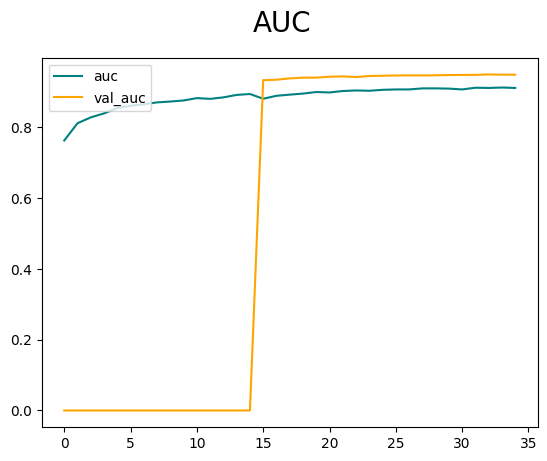

In [14]:
import pandas as pd
import matplotlib.pyplot as plt

log = pd.read_csv("training_log.csv")

# Loss
fig = plt.figure()
plt.plot(log['loss'], color='teal', label='loss')
plt.plot(log['val_loss'], color='orange', label='val_loss')
fig.suptitle('Loss', fontsize=20)
plt.legend(loc="upper left")
plt.show()

# Accuracy
fig = plt.figure()
plt.plot(log['accuracy'], color='teal', label='accuracy')
plt.plot(log['val_accuracy'], color='orange', label='val_accuracy')
fig.suptitle('Accuracy', fontsize=20)
plt.legend(loc="upper left")
plt.show()

# AUC
fig = plt.figure()
plt.plot(log['auc'], color='teal', label='auc')
plt.plot(log['val_auc'], color='orange', label='val_auc')
fig.suptitle('AUC', fontsize=20)
plt.legend(loc="upper left")
plt.show()

## Re-adding new data cause I messed up folder paths

In [5]:
import shutil
import os
import random

random.seed(42)

for label, folders in [
    ("fake", ["data/real-vs-fake/train/fake", "data/AI-face-detection-Dataset/AI"]),
    ("real", ["data/real-vs-fake/train/real", "data/AI-face-detection-Dataset/real"])
]:
    # Collect all images from all sources
    all_images = []
    for folder in folders:
        all_images += [os.path.join(folder, img) for img in os.listdir(folder)]
    
    random.shuffle(all_images)
    
    n = len(all_images)
    train_end = int(n * 0.7)
    val_end = int(n * 0.85)
    
    splits = {
        "train": all_images[:train_end],
        "val": all_images[train_end:val_end],
        "test": all_images[val_end:]
    }
    
    for split, imgs in splits.items():
        os.makedirs(f"data/splits/{split}/{label}", exist_ok=True)
        for img_path in imgs:
            shutil.copy(img_path, f"data/splits/{split}/{label}/{os.path.basename(img_path)}")

# Sanity check
for split in ["train", "val", "test"]:
    for label in ["fake", "real"]:
        print(f"{split}/{label}:", len(os.listdir(f"data/splits/{split}/{label}")))

train/fake: 14362
train/real: 14862
val/fake: 3155
val/real: 3373
test/fake: 3158
test/real: 3356


In [6]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = tf.keras.utils.image_dataset_from_directory(
    "data/splits/train",
    seed=42,
    image_size=(160, 160),
    batch_size=64,
    label_mode="int"
).cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)

val_ds = tf.keras.utils.image_dataset_from_directory(
    "data/splits/val",
    image_size=(160, 160),
    batch_size=64,
    label_mode="int"
).cache().prefetch(buffer_size=AUTOTUNE)

test_ds = tf.keras.utils.image_dataset_from_directory(
    "data/splits/test",
    image_size=(160, 160),
    batch_size=64,
    label_mode="int"
).cache().prefetch(buffer_size=AUTOTUNE)

Found 29224 files belonging to 2 classes.
Found 6528 files belonging to 2 classes.
Found 6514 files belonging to 2 classes.


In [7]:
model = tf.keras.models.load_model("best_model.keras")

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-4),
    loss="binary_crossentropy",
    metrics=[
        "accuracy",
        tf.keras.metrics.AUC(name="auc", curve="ROC", from_logits=False),
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.Recall(name="recall"),
    ]
)

In [8]:
log = pd.read_csv("training_log.csv")
last_epoch = int(log["epoch"].max()) + 1

callbacks = [
    tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=4, restore_best_weights=True),
    tf.keras.callbacks.ModelCheckpoint("best_model.keras", monitor="val_loss", save_best_only=True),
    tf.keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=2, min_lr=1e-6, verbose=1),
    tf.keras.callbacks.CSVLogger("training_log.csv", append=True),
]

model.fit(
    train_ds,
    validation_data=val_ds,
    initial_epoch=last_epoch,
    epochs=last_epoch + 15,
    callbacks=callbacks,
)

Epoch 36/50
457/457 ━━━━━━━━━━━━━━━━━━━━ 845s 2s/step - accuracy: 0.8274 - auc: 0.9090 - loss: 0.3808 - precision: 0.8351 - recall: 0.8230 - val_accuracy: 0.8799 - val_auc: 0.9543 - val_loss: 0.2986 - val_precision: 0.8670 - val_recall: 0.9066 - learning_rate: 1.0000e-04
Epoch 37/50
457/457 ━━━━━━━━━━━━━━━━━━━━ 763s 2s/step - accuracy: 0.8353 - auc: 0.9153 - loss: 0.3684 - precision: 0.8445 - recall: 0.8288 - val_accuracy: 0.8790 - val_auc: 0.9556 - val_loss: 0.2937 - val_precision: 0.8596 - val_recall: 0.9152 - learning_rate: 1.0000e-04
Epoch 38/50
457/457 ━━━━━━━━━━━━━━━━━━━━ 760s 2s/step - accuracy: 0.8315 - auc: 0.9148 - loss: 0.3686 - precision: 0.8386 - recall: 0.8280 - val_accuracy: 0.8797 - val_auc: 0.9549 - val_loss: 0.2904 - val_precision: 0.8647 - val_recall: 0.9096 - learning_rate: 1.0000e-04
Epoch 39/50
457/457 ━━━━━━━━━━━━━━━━━━━━ 741s 2s/step - accuracy: 0.8327 - auc: 0.9140 - loss: 0.3711 - precision: 0.8402 - recall: 0.8286 - val_accuracy: 0.8721 - val_auc: 0.9553 - va

## Evaluate on test set

In [8]:
model = tf.keras.models.load_model("best_model.keras")

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-4),
    loss="binary_crossentropy",
    metrics=[
        "accuracy",
        tf.keras.metrics.AUC(name="auc", curve="ROC", from_logits=False),
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.Recall(name="recall"),
    ]
)

results = model.evaluate(test_ds)
print(dict(zip(model.metrics_names, results)))

102/102 ━━━━━━━━━━━━━━━━━━━━ 150s 1s/step - accuracy: 0.8875 - auc: 0.9566 - loss: 0.2878 - precision: 0.8805 - recall: 0.9044
{'loss': 0.2877996265888214, 'compile_metrics': 0.8874731063842773}
